# Step 1-2: Canny + Soft Crop and MediaPipe

c:\Users\ADV\Universita\Magistrale\CV\Guitar-Chords-Recognition\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Success: Hand found on the fretboard!


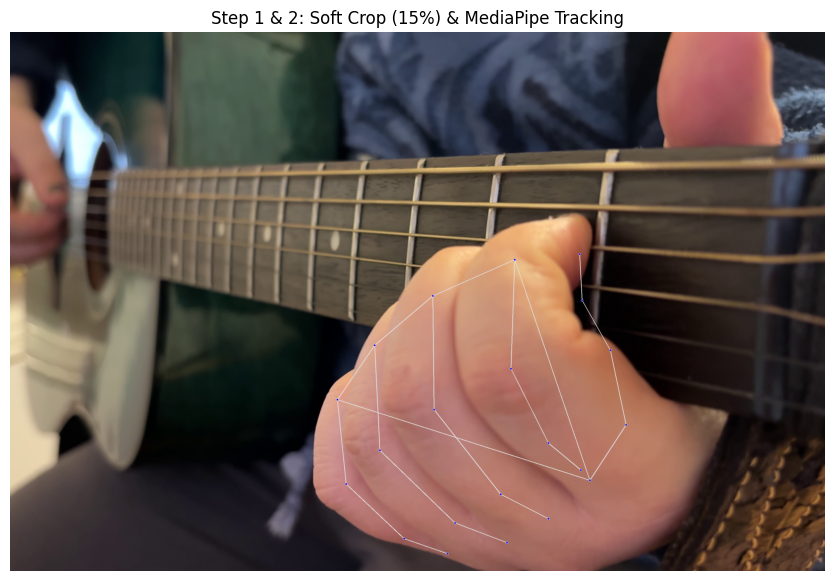

In [1]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
processed_frame_path = "../data/processed_frames/A_01_seg1_A.jpg"
video_path = "../data/raw_videos/A_01.mp4"
target_time_sec = 6.210

# 1. CANNY EDGE DETECTION (Our trusted baseline)
processed_image = cv2.imread(processed_frame_path, cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(processed_image, 30, 90)

# 2. COLOR FRAME EXTRACTION (For MediaPipe)
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, target_time_sec * 1000.0)
success, original_frame = cap.read()
cap.release()

if success:
    frame_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
    height, width, _ = frame_rgb.shape
    
    # --- THE NEW SOFT CROP ---
    # Cut off only 15% from the left (picking hand) and keep 85% on the right
    crop_offset_x = int(width * 0.15)
    soft_crop_img = frame_rgb[:, crop_offset_x:].copy()
    
    # Initialize MediaPipe (with the settings that worked previously)
    mp_hands = mp.solutions.hands
    mp_drawing = mp.solutions.drawing_utils
    hands = mp_hands.Hands(
        static_image_mode=True, 
        max_num_hands=1, 
        min_detection_confidence=0.1, 
        model_complexity=1
    )
    
    # Process the cropped image
    results = hands.process(soft_crop_img)
    annotated_image = soft_crop_img.copy()
    
    if results.multi_hand_landmarks:
        print("Success: Hand found on the fretboard!")
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                annotated_image, 
                hand_landmarks, 
                mp_hands.HAND_CONNECTIONS
            )
    else:
        print("Warning: Hand not detected.")
        
    # Display the result
    plt.figure(figsize=(12, 7))
    plt.imshow(annotated_image)
    plt.title('Step 1 & 2: Soft Crop (15%) & MediaPipe Tracking')
    plt.axis('off')
    plt.show()
    
    hands.close()
else:
    print("Error loading the original frame.")

# Step 3 - ROI Creation

Surgery successful: Hand masked at X(1879-3051), Y(882-2098)


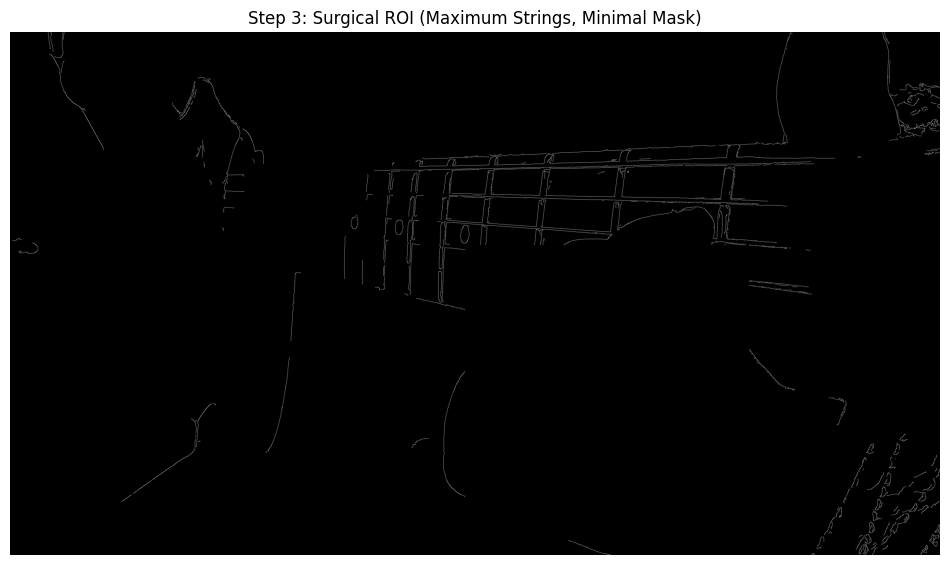

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Start with a fresh copy of the FULL Canny image from Step 1
# This ensures we preserve ALL the beautiful strings on the left
full_edges_refined = edges.copy()
height, width = full_edges_refined.shape

# 2. This MUST match the offset used in Step 2 (15% of width)
crop_offset_x = int(width * 0.15)
cropped_width = width - crop_offset_x

if results.multi_hand_landmarks:
    # We only care about the first hand detected (the one on the fretboard)
    hand_landmarks = results.multi_hand_landmarks[0]
    
    # 3. Extract coordinates and scale them back to the FULL image size
    # x is relative to the cropped image, so we add the offset back
    x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hand_landmarks.landmark]
    y_coords = [int(l.y * height) for l in hand_landmarks.landmark]
    
    # 4. Find the exact tight boundaries of the fingers
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    # 5. Apply a VERY TIGHT padding (e.g., just 8 pixels)
    # We want to cover the knuckles but keep the strings right next to them intact
    padding = 8
    x_min = max(0, x_min - padding)
    x_max = min(width, x_max + padding)
    y_min = max(0, y_min - padding)
    y_max = min(height, y_max + padding)
    
    # 6. Draw the black surgical mask ONLY over the hand area
    cv2.rectangle(full_edges_refined, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    
    print(f"Surgery successful: Hand masked at X({x_min}-{x_max}), Y({y_min}-{y_max})")
else:
    print("Warning: No hand detected to mask.")

# 7. Show the refined ROI
plt.figure(figsize=(12, 7))
plt.imshow(full_edges_refined, cmap='gray')
plt.title('Step 3: Surgical ROI (Maximum Strings, Minimal Mask)')
plt.axis('off')
plt.show()

# Step 4: Hough Standard (version 1)

Standard Hough projected 73 lines for strings and 5 lines for frets.


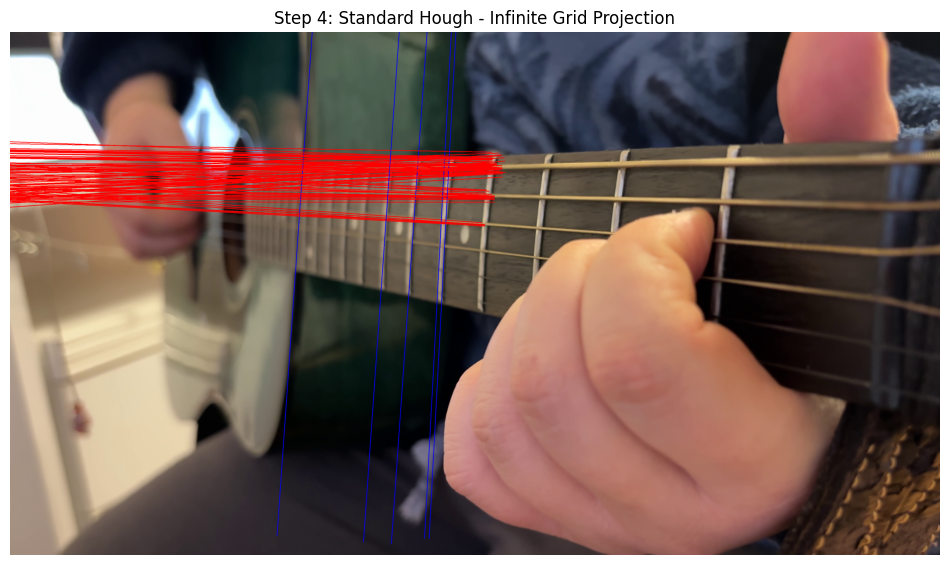

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a color copy of the original frame to clearly visualize the final result
hough_grid_img = original_frame.copy()

# Use the STANDARD Hough Transform (finds infinite lines)
# rho=1, theta=pi/180 define the resolution. 
# threshold=120 means: "draw a line only if at least 120 pixels vote for that trajectory"
lines_std = cv2.HoughLines(full_edges_refined, 1, np.pi / 180, 120)

strings_found = 0
frets_found = 0

if lines_std is not None:
    for line in lines_std:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        
        # Calculate distant points to draw the line across the entire screen
        x1 = int(x0 + 2000 * (-b))
        y1 = int(y0 + 2000 * (a))
        x2 = int(x0 - 2000 * (-b))
        y2 = int(y0 - 2000 * (a))
        
        angle = np.degrees(theta)
        
        # STRINGS FILTER (Horizontal): In this system, theta near 90 degrees indicates horizontal lines
        if 85 < angle < 95:
            cv2.line(hough_grid_img, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED for strings
            strings_found += 1
            
        # FRETS FILTER (Vertical): theta near 0 or 180 degrees indicates vertical lines
        elif angle < 5 or angle > 175:
            cv2.line(hough_grid_img, (x1, y1), (x2, y2), (255, 0, 0), 2) # BLUE for frets
            frets_found += 1

print(f"Standard Hough projected {strings_found} lines for strings and {frets_found} lines for frets.")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(hough_grid_img, cv2.COLOR_BGR2RGB))
plt.title('Step 4: Standard Hough - Infinite Grid Projection')
plt.axis('off')
plt.show()

# Test with Sobel Y 

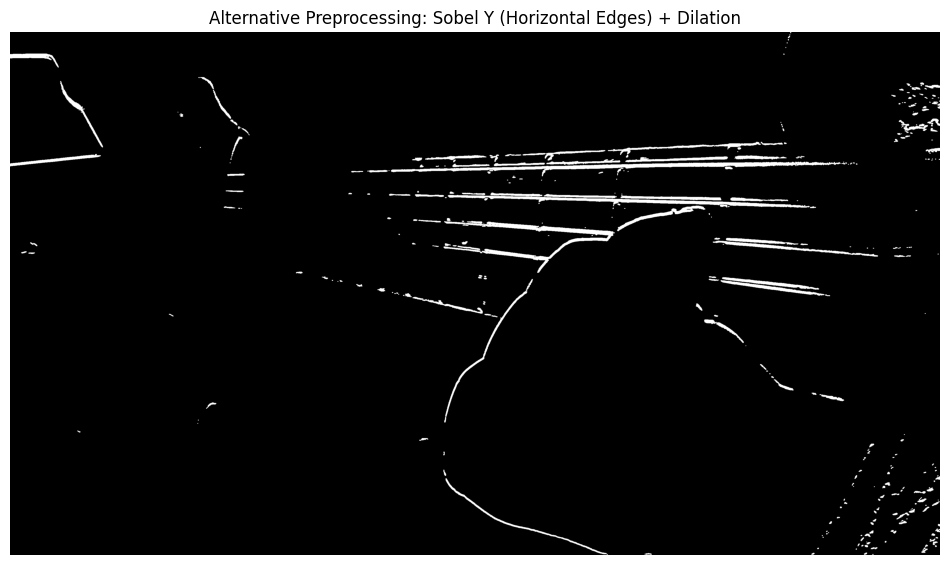

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Convert to grayscale
gray = cv2.cvtColor(original_frame, cv2.COLOR_BGR2GRAY)

# 2. Slight blur to remove grain/noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. THE MAGIC: Sobel Y Filter 
# This specifically looks for HORIZONTAL edges (strings) and ignores vertical ones (frets/fingers)
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# 4. Thresholding: Turn the strongest horizontal edges into pure white
_, thresh_strings = cv2.threshold(abs_sobel_y, 40, 255, cv2.THRESH_BINARY)

# 5. Morphological Dilation: The cure for "Double Lines"
# We use a horizontal kernel to thicken the lines horizontally and merge the top/bottom edges
kernel = np.ones((3, 3), np.uint8)
merged_strings = cv2.dilate(thresh_strings, kernel, iterations=1)

# Display the new Pre-processing approach
plt.figure(figsize=(12, 7))
plt.imshow(merged_strings, cmap='gray')
plt.title('Alternative Preprocessing: Sobel Y (Horizontal Edges) + Dilation')
plt.axis('off')
plt.show()

Surgical mask applied to Sobel edges.
Extraction complete: Found 176 string segments.


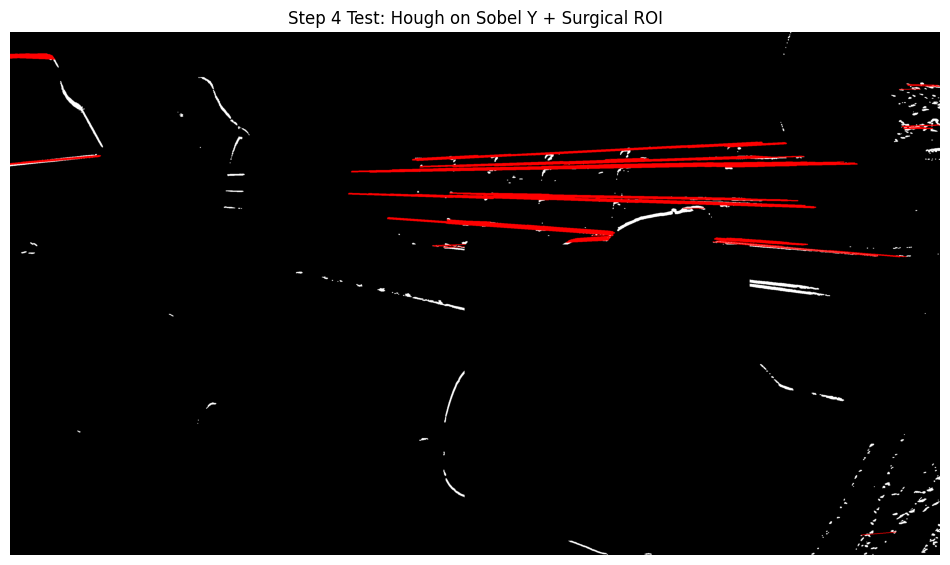

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. ASSIGN YOUR IMAGE HERE (Replace 'sobel_y_dilated' with your actual variable name)
current_edges = merged_strings.copy() 
height, width = current_edges.shape

# 2. APPLY SURGICAL ROI (Using the coordinates from the MediaPipe step)
crop_offset_x = int(width * 0.15)
cropped_width = width - crop_offset_x

if 'results' in locals() and results.multi_hand_landmarks:
    hand_landmarks = results.multi_hand_landmarks[0]
    
    x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hand_landmarks.landmark]
    y_coords = [int(l.y * height) for l in hand_landmarks.landmark]
    
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    padding = 10
    x_min = max(0, x_min - padding)
    x_max = min(width, x_max + padding)
    y_min = max(0, y_min - padding)
    y_max = min(height, y_max + padding)
    
    # Draw the surgical mask
    cv2.rectangle(current_edges, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    print("Surgical mask applied to Sobel edges.")

# 3. HOUGH LINES PROBABILISTIC (Searching for Strings only)
hough_viz = cv2.cvtColor(current_edges, cv2.COLOR_GRAY2BGR)

# Parameters to bridge the gap and catch thick lines
lines = cv2.HoughLinesP(
    current_edges, 
    rho=1, 
    theta=np.pi/180, 
    threshold=50,       # Lower threshold to catch more segments
    minLineLength=80,   # Strings are long
    maxLineGap=120      # BIG GAP to jump over the masked hand
)

strings_found = 0
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # Filter for HORIZONTAL lines only (+/- 5 degrees)
        if angle < 5 or angle > 175:
            cv2.line(hough_viz, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED for Strings
            strings_found += 1

print(f"Extraction complete: Found {strings_found} string segments.")

# 4. VISUALIZE RESULT
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(hough_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 4 Test: Hough on Sobel Y + Surgical ROI')
plt.axis('off')
plt.show()

 # Step 1: Setup and MediaPipe (HandTracking)

c:\Users\ADV\Universita\Magistrale\CV\Guitar-Chords-Recognition\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


MediaPipe: Hand successfully detected on the fretboard.


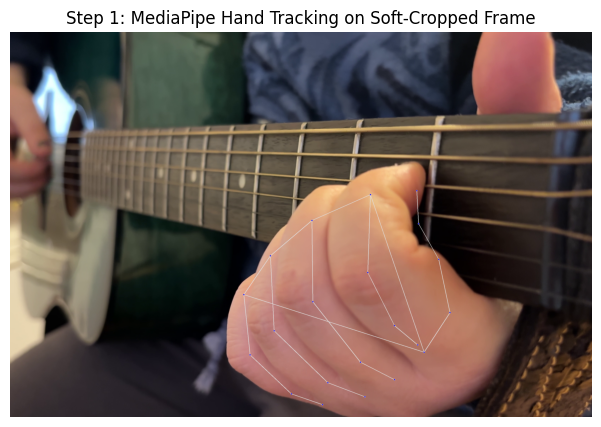

In [7]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
video_path = "../data/raw_videos/A_01.mp4"
target_time_sec = 6.210

# 1. EXTRACT RAW FRAME
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, target_time_sec * 1000.0)
success, original_frame = cap.read()
cap.release()

if not success:
    raise ValueError("Error loading the video frame.")

frame_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
height, width, _ = frame_rgb.shape

# 2. MEDIAPIPE TRACKING (With 15% Soft Crop to ignore picking hand)
crop_offset_x = int(width * 0.15)
soft_crop_img = frame_rgb[:, crop_offset_x:].copy()

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.1, model_complexity=1)
results = hands.process(soft_crop_img)

# Visualization
annotated_image = soft_crop_img.copy()
if results.multi_hand_landmarks:
    mp.solutions.drawing_utils.draw_landmarks(annotated_image, results.multi_hand_landmarks[0], mp_hands.HAND_CONNECTIONS)
    print("MediaPipe: Hand successfully detected on the fretboard.")
else:
    print("MediaPipe: Warning, hand not detected.")

plt.figure(figsize=(10, 5))
plt.imshow(annotated_image)
plt.title('Step 1: MediaPipe Hand Tracking on Soft-Cropped Frame')
plt.axis('off')
plt.show()

# Step 2: Sobel Y Preprocessing (Isolating Horizontal Edges)

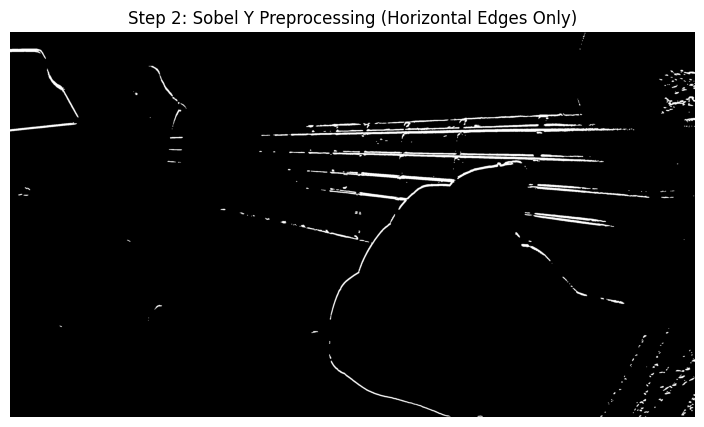

In [8]:
# 1. Convert original raw frame to grayscale
gray = cv2.cvtColor(original_frame, cv2.COLOR_BGR2GRAY)

# 2. Gaussian Blur to reduce high-frequency noise (sweater texture, wood grain)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Sobel Y: The magic filter that highlights horizontal edges and kills vertical ones
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# 4. Thresholding: Binarize the strongest horizontal edges
_, thresh_strings = cv2.threshold(abs_sobel_y, 40, 255, cv2.THRESH_BINARY)

# 5. Dilation: Thicken the lines slightly to repair small breaks
kernel = np.ones((3, 3), np.uint8)
preprocessed_strings = cv2.dilate(thresh_strings, kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.imshow(preprocessed_strings, cmap='gray')
plt.title('Step 2: Sobel Y Preprocessing (Horizontal Edges Only)')
plt.axis('off')
plt.show()

# Step 3: ROI (Noise and hand Removal) (version 2)

Asymmetric mask applied. Y-Top extended by 180 pixels.


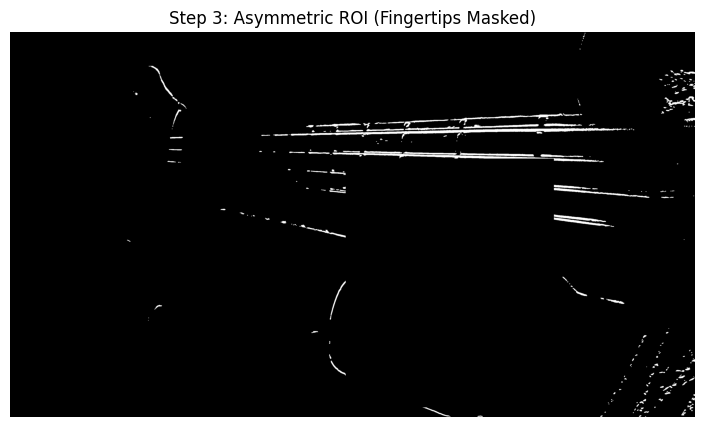

In [46]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a fresh copy of the preprocessed image
roi_strings = preprocessed_strings.copy()

# 1. NOISE MASK: Black out the left 15% completely 
cv2.rectangle(roi_strings, (0, 0), (crop_offset_x, height), (0, 0, 0), -1)

# 2. ASYMMETRIC SURGICAL MASK (The Fingertip Killer)
if 'results' in locals() and results.multi_hand_landmarks:
    hand_landmarks = results.multi_hand_landmarks[0]
    cropped_width = width - crop_offset_x
    
    # Map coordinates back to full image scale
    x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hand_landmarks.landmark]
    y_coords = [int(l.y * height) for l in hand_landmarks.landmark]
    
    # --- ASYMMETRIC PADDING ---
    padding_x = 5           # Keep sides tight to save horizontal string length
    padding_y_top = 180      # VERY GENEROUS ON TOP: Kill the fleshy fingertips!
    padding_y_bottom = 15   # A bit of safety margin on the bottom
    
    x_min = max(0, min(x_coords) - padding_x)
    x_max = min(width, max(x_coords) + padding_x)
    y_min = max(0, min(y_coords) - padding_y_top)
    y_max = min(height, max(y_coords) + padding_y_bottom)
    
    # Draw the surgical black box
    cv2.rectangle(roi_strings, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    print(f"Asymmetric mask applied. Y-Top extended by {padding_y_top} pixels.")

plt.figure(figsize=(10, 5))
plt.imshow(roi_strings, cmap='gray')
plt.title('Step 3: Asymmetric ROI (Fingertips Masked)')
plt.axis('off')
plt.show()

## Step 4 (Phase A): Hough Transform (String Extraction) version 2

Extraction complete: Found 228 raw string segments.


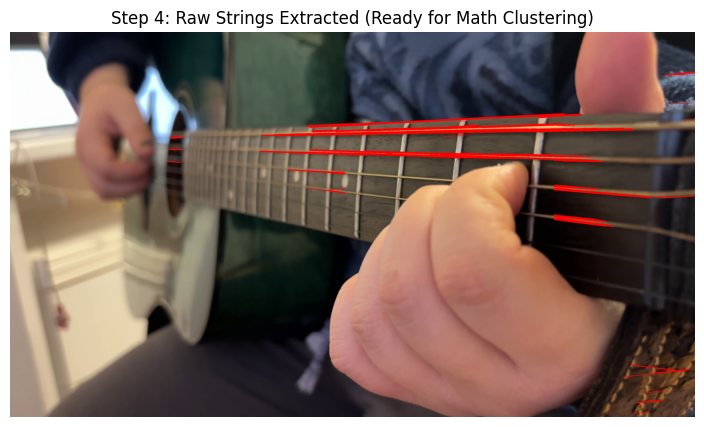

In [48]:
# Canvas for drawing the final lines
hough_strings_viz = original_frame.copy()

# Probabilistic Hough Transform optimized for long horizontal lines with gaps
lines_horizontal = cv2.HoughLinesP(
    roi_strings, 
    rho=1, 
    theta=np.pi/180, 
    threshold=35,       # Minimum votes
    minLineLength=40,   # Strings are long segments
    maxLineGap=150      # Jump over the surgical hand mask
)

raw_strings_data = [] # We will save these for the clustering phase

if lines_horizontal is not None:
    for line in lines_horizontal:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # Strict filter: keep only lines perfectly horizontal (+/- 8 degrees)
        if angle < 8 or angle > 172:
            cv2.line(hough_strings_viz, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED
            raw_strings_data.append(line[0])

print(f"Extraction complete: Found {len(raw_strings_data)} raw string segments.")

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(hough_strings_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 4: Raw Strings Extracted (Ready for Math Clustering)')
plt.axis('off')
plt.show()